In [ ]:
# ============================================================
# 1. Cargar librerías
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize

In [ ]:
# ============================================================
# 2. Leer archivo
# ============================================================

# Cargamos el archivo CSV
df = pd.read_csv("dtree_client_classification.csv")

# Vemos las primeras filas
df.head()

,Age,Income,Visits_Last_Month,Avg_Purchase_Value,Months_as_Client,Client_Type
0,56,9901,11,375.56,36,High Potential
1,69,6575,11,295.85,56,Stable
2,46,6530,4,481.46,32,Stable
3,32,5413,6,193.69,52,Stable
4,60,4748,3,150.00,21,Stable


In [ ]:
# ============================================================
# 3. EDA - Exploración inicial de datos
# ============================================================

# Revisamos el tamaño del dataset
df.shape

(200, 6)

In [ ]:
# Vemos los nombres de las columnas
df.columns

Index(['Age', 'Income', 'Visits_Last_Month', 'Avg_Purchase_Value',
       'Months_as_Client', 'Client_Type'],
      dtype='object')

In [ ]:
# Revisamos información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 200 non-null    int64  
 1   Income              200 non-null    int64  
 2   Visits_Last_Month   200 non-null    int64  
 3   Avg_Purchase_Value  200 non-null    float64
 4   Months_as_Client    200 non-null    int64  
 5   Client_Type         200 non-null    object 
dtypes: float64(1), int64(4), object(1)
memory usage: 9.5+ KB


In [ ]:
# Revisamos valores nulos
df.isnull().sum()

,0
Age,0
Income,0
Visits_Last_Month,0
Avg_Purchase_Value,0
Months_as_Client,0
Client_Type,0


In [ ]:
# Revisamos la variable objetivo
df["Client_Type"].value_counts()

,count
Client_Type,
Stable,149
High Potential,34
New,12
Possible Churn,5


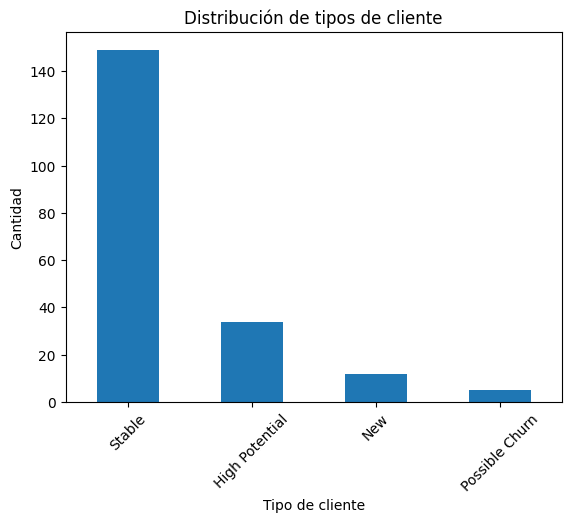

In [ ]:
# Visualizamos la distribución de la variable objetivo

df["Client_Type"].value_counts().plot(kind="bar")

plt.title("Distribución de tipos de cliente")
plt.xlabel("Tipo de cliente")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

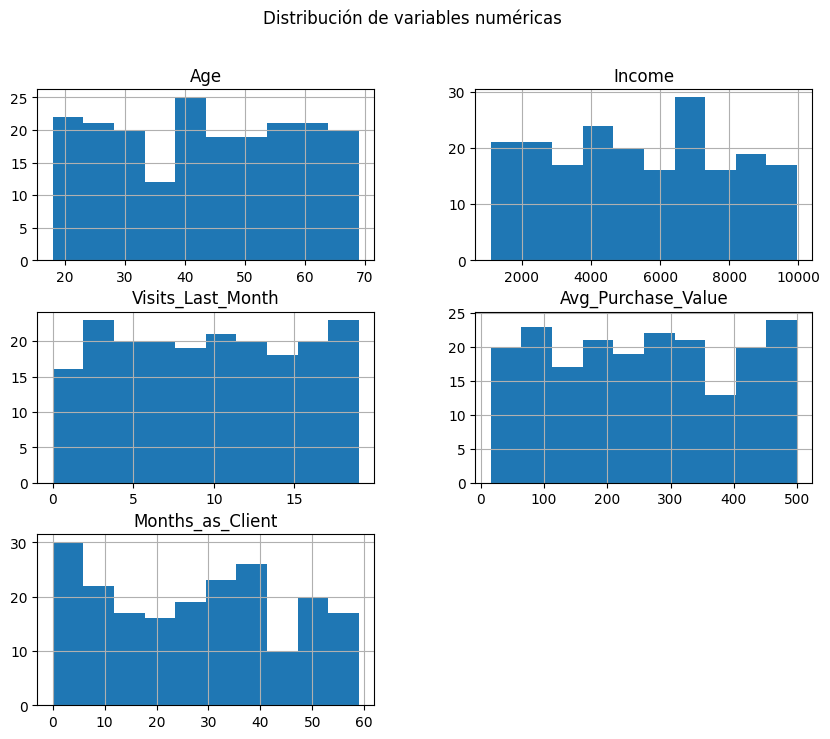

In [ ]:
# Visualizamos histogramas de las variables numéricas

df.hist(figsize=(10, 8))

plt.suptitle("Distribución de variables numéricas")
plt.show()

In [ ]:
# Revisamos correlación entre variables numéricas

df.corr(numeric_only=True)

,Age,Income,Visits_Last_Month,Avg_Purchase_Value,Months_as_Client
Age,1.000000,-0.075528,-0.129355,0.008341,-0.097277
Income,-0.075528,1.000000,0.231974,0.065537,-0.086406
Visits_Last_Month,-0.129355,0.231974,1.000000,-0.061297,0.013650
Avg_Purchase_Value,0.008341,0.065537,-0.061297,1.000000,-0.160058
Months_as_Client,-0.097277,-0.086406,0.013650,-0.160058,1.000000


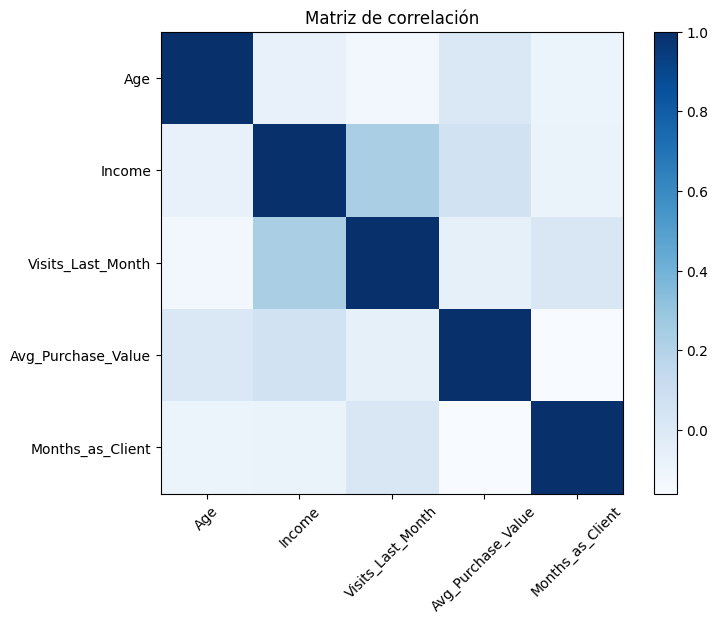

In [ ]:
# Visualizamos la matriz de correlación

plt.figure(figsize=(8, 6))

plt.imshow(df.corr(numeric_only=True), cmap="Blues")
plt.colorbar()

plt.xticks(range(len(df.corr(numeric_only=True).columns)), df.corr(numeric_only=True).columns, rotation=45)
plt.yticks(range(len(df.corr(numeric_only=True).columns)), df.corr(numeric_only=True).columns)

plt.title("Matriz de correlación")
plt.show()

In [ ]:
# ============================================================
# 4. Definir variable objetivo
# ============================================================

# La variable objetivo es el tipo de cliente
variable_objetivo = "Client_Type"

# Revisamos las categorías posibles
df[variable_objetivo].unique()

array(['High Potential', 'Stable', 'New', 'Possible Churn'], dtype=object)

In [ ]:
# ============================================================
# 5. Generar X e y
# ============================================================

# X son las variables predictoras
X = df.drop(columns=[variable_objetivo])

# y es la variable objetivo
y = df[variable_objetivo]

# Revisamos X
X.head()

,Age,Income,Visits_Last_Month,Avg_Purchase_Value,Months_as_Client
0,56,9901,11,375.56,36
1,69,6575,11,295.85,56
2,46,6530,4,481.46,32
3,32,5413,6,193.69,52
4,60,4748,3,150.00,21


In [ ]:
# Revisamos y
y.head()

,Client_Type
0,High Potential
1,Stable
2,Stable
3,Stable
4,Stable


In [ ]:
# ============================================================
# 6. Eliminar columnas no necesarias
# ============================================================

# En este dataset no hay columnas tipo ID o columnas claramente innecesarias.
# Por eso mantenemos todas las variables predictoras.

X.head()

,Age,Income,Visits_Last_Month,Avg_Purchase_Value,Months_as_Client
0,56,9901,11,375.56,36
1,69,6575,11,295.85,56
2,46,6530,4,481.46,32
3,32,5413,6,193.69,52
4,60,4748,3,150.00,21


In [ ]:
# ============================================================
# 7. Imputación de datos
# ============================================================

# Revisamos valores nulos en X
X.isnull().sum()

,0
Age,0
Income,0
Visits_Last_Month,0
Avg_Purchase_Value,0
Months_as_Client,0


In [ ]:
# Imputamos variables numéricas con la mediana
# Esto sirve por si aparece algún valor vacío

for columna in X.columns:
    if X[columna].dtype in ["int64", "float64"]:
        X[columna] = X[columna].fillna(X[columna].median())

In [ ]:
# Imputamos variables categóricas con la moda
# En este caso no hay variables categóricas en X, pero dejamos el paso como buena práctica

for columna in X.columns:
    if X[columna].dtype == "object":
        X[columna] = X[columna].fillna(X[columna].mode()[0])

In [ ]:
# ============================================================
# 8. Variables Dummy si hace falta
# ============================================================

# Convertimos variables categóricas en variables dummy si existen
X = pd.get_dummies(X, drop_first=True)

# Revisamos el resultado
X.head()

,Age,Income,Visits_Last_Month,Avg_Purchase_Value,Months_as_Client
0,56,9901,11,375.56,36
1,69,6575,11,295.85,56
2,46,6530,4,481.46,32
3,32,5413,6,193.69,52
4,60,4748,3,150.00,21


In [ ]:
# ============================================================
# 9. Codificar la variable objetivo
# ============================================================

# Convertimos las categorías de y a números
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

# Revisamos las clases originales
encoder.classes_

array(['High Potential', 'New', 'Possible Churn', 'Stable'], dtype=object)

In [ ]:
# ============================================================
# 10. Dividir en Training y Testing
# ============================================================

# Dividimos los datos en entrenamiento y prueba
# stratify ayuda a mantener proporciones similares de clases

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

# Revisamos tamaños
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (140, 5)
X_test: (60, 5)
y_train: (140,)
y_test: (60,)


In [ ]:
# ============================================================
# 11. Escalar datos si es necesario
# ============================================================

# Para un árbol CART no es necesario escalar los datos.
# Los árboles trabajan con cortes sobre las variables y no dependen de distancias.

X_train.head()

,Age,Income,Visits_Last_Month,Avg_Purchase_Value,Months_as_Client
18,19,2636,18,318.41,54
38,61,3327,13,352.10,55
157,49,5014,11,376.65,13
66,67,9155,16,37.62,36
191,56,2148,6,375.27,1


In [ ]:
# ============================================================
# 12. Crear el modelo CART
# ============================================================

# Creamos el modelo de árbol de decisión
modelo_cart = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

# Entrenamos el modelo
modelo_cart.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=3, min_samples_split=5,
                       random_state=42)

In [ ]:
# ============================================================
# 13. Hacer predicciones
# ============================================================

# Generamos predicciones con el set de prueba
y_pred = modelo_cart.predict(X_test)

# Generamos probabilidades para la curva ROC
y_prob = modelo_cart.predict_proba(X_test)

# Revisamos algunas predicciones
y_pred[:10]

array([3, 3, 3, 3, 1, 3, 0, 3, 3, 3])

In [ ]:
# ============================================================
# 14. Métricas del modelo - Clasificación
# ============================================================

# Calculamos el accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy del modelo:", round(accuracy, 4))

Accuracy del modelo: 0.9667


In [ ]:
# Reporte completo de clasificación

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

                precision    recall  f1-score   support

High Potential       0.83      1.00      0.91        10
           New       1.00      0.50      0.67         4
Possible Churn       1.00      1.00      1.00         1
        Stable       1.00      1.00      1.00        45

      accuracy                           0.97        60
     macro avg       0.96      0.88      0.89        60
  weighted avg       0.97      0.97      0.96        60



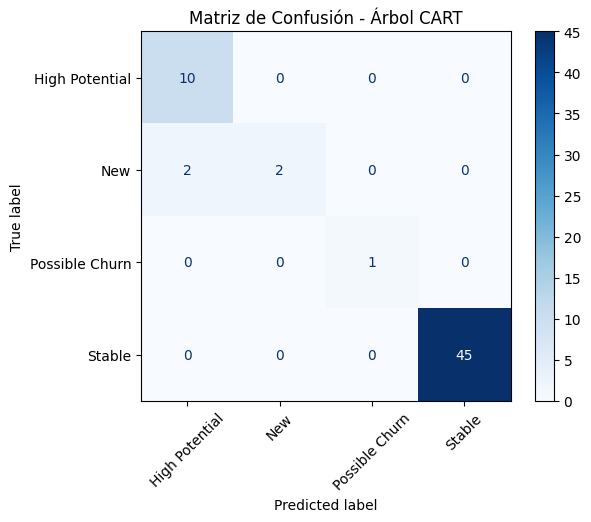

In [ ]:
# ============================================================
# 15. Matriz de confusión
# ============================================================

# Creamos la matriz de confusión
matriz = confusion_matrix(y_test, y_pred)

# Visualizamos la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Matriz de Confusión - Árbol CART")
plt.xticks(rotation=45)
plt.show()

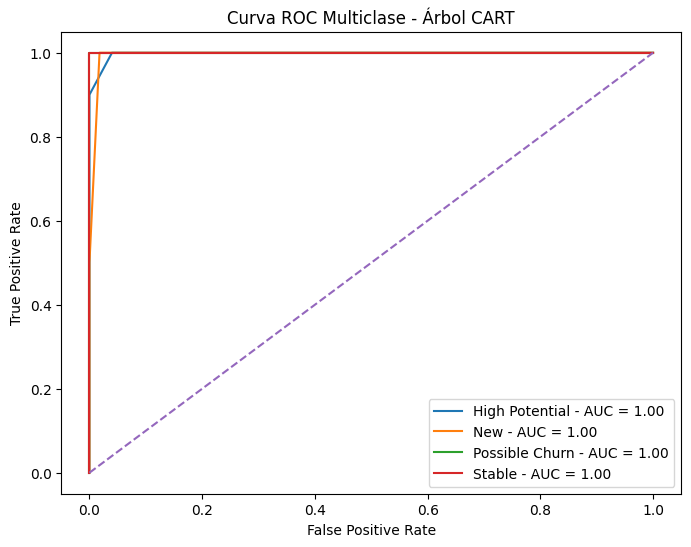

In [ ]:
# ============================================================
# 16. Curva ROC Multiclase
# ============================================================

# Binarizamos y_test para poder calcular ROC multiclase
y_test_bin = label_binarize(y_test, classes=np.unique(y_encoded))

# Número de clases
n_clases = y_test_bin.shape[1]

# Creamos la curva ROC para cada clase
plt.figure(figsize=(8, 6))

for i in range(n_clases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{encoder.classes_[i]} - AUC = {roc_auc:.2f}"
    )

# Línea base
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Curva ROC Multiclase - Árbol CART")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

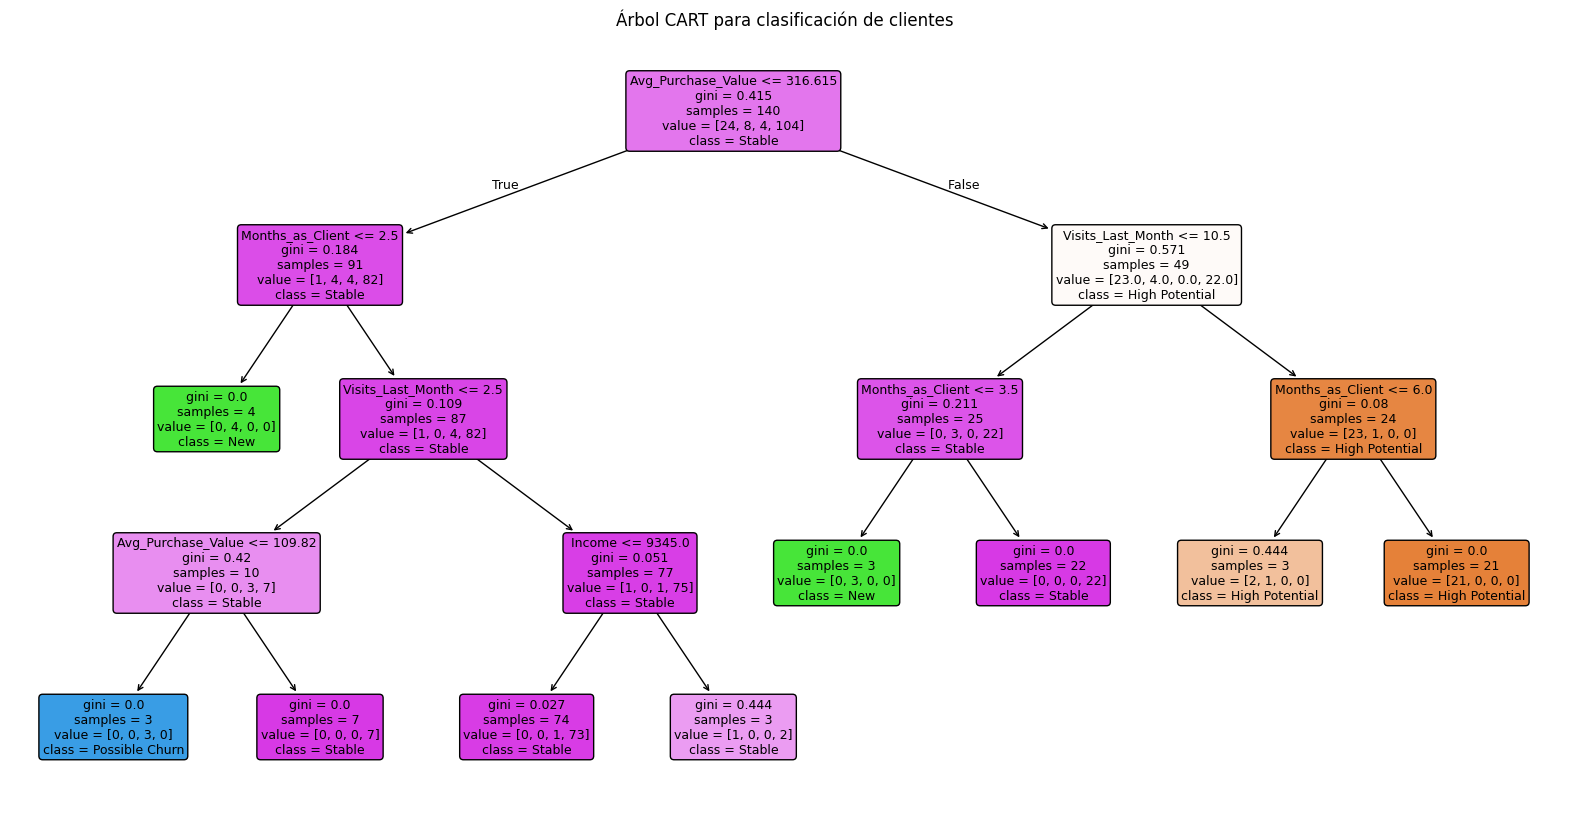

In [ ]:
# ============================================================
# 17. Visualizar el árbol
# ============================================================

plt.figure(figsize=(20, 10))

plot_tree(
    modelo_cart,
    feature_names=X.columns,
    class_names=encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Árbol CART para clasificación de clientes")
plt.show()

In [ ]:
# ============================================================
# 18. Importancia de variables
# ============================================================

# Creamos una tabla con la importancia de cada variable
importancia = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_cart.feature_importances_
})

# Ordenamos de mayor a menor
importancia = importancia.sort_values(by="Importancia", ascending=False)

importancia

,Variable,Importancia
2,Visits_Last_Month,0.415566
3,Avg_Purchase_Value,0.327793
4,Months_as_Client,0.245113
1,Income,0.011528
0,Age,0.000000


In [ ]:
# ============================================================
# 19. Comparar valores reales vs predichos
# ============================================================

# Creamos una tabla para comparar resultados
resultados = pd.DataFrame({
    "Real": encoder.inverse_transform(y_test),
    "Predicción": encoder.inverse_transform(y_pred)
})

resultados.head(20)

,Real,Predicción
0,Stable,Stable
1,Stable,Stable
2,Stable,Stable
3,Stable,Stable
4,New,New
5,Stable,Stable
6,High Potential,High Potential
7,Stable,Stable
8,Stable,Stable
9,Stable,Stable


In [ ]:
# ============================================================
# 20. Interfaz simple de predicción
# ============================================================

# Ingresamos datos de un nuevo cliente

edad = 40
ingreso = 6000
visitas_ultimo_mes = 8
valor_promedio_compra = 120.5
meses_como_cliente = 24

# Creamos un dataframe con el nuevo cliente
nuevo_cliente = pd.DataFrame({
    "Age": [edad],
    "Income": [ingreso],
    "Visits_Last_Month": [visitas_ultimo_mes],
    "Avg_Purchase_Value": [valor_promedio_compra],
    "Months_as_Client": [meses_como_cliente]
})

# Revisamos el nuevo cliente
nuevo_cliente

,Age,Income,Visits_Last_Month,Avg_Purchase_Value,Months_as_Client
0,40,6000,8,120.5,24
